## Clustering (KMeans and GMM)

* *Identifying different clusters in crime data using feature selection and dimensionality.*

* *We shall use both rigid (Kmeans) and soft/probabilistic (Gaussian Mixture Models)*


### Load and Inspect the dataset

In [101]:
import pandas as pd 

arrest_df = pd.read_csv('USArrests.csv')
# instead of arrest_df = arrest_df.drop(columns='rownames')
arrest_df = arrest_df.rename(columns={'rownames': 'State'})

In [102]:
arrest_df.head()

,State,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


*Crime rates per state*

In [103]:
arrest_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   State     50 non-null     str    
 1   Murder    50 non-null     float64
 2   Assault   50 non-null     int64  
 3   UrbanPop  50 non-null     int64  
 4   Rape      50 non-null     float64
dtypes: float64(2), int64(2), str(1)
memory usage: 2.1 KB


*All our target variables are in numerical values*

In [104]:
arrest_df.describe()

,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


*Kmeans uses Euclidean distance, the diff scales and Standard Devations will have to be standardized*

In [105]:
arrest_df.isnull().sum()

State       0
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64

In [106]:
arrest_df.duplicated().sum()

np.int64(0)

*The dataset has no missing values nor duplicated values*
___

In [107]:
# Standardize
from sklearn.preprocessing import StandardScaler

feature_cols = ['Murder', 'Assault', 'Rape', 'UrbanPop']  
scaler = StandardScaler()
arrest_scaled = scaler.fit_transform(arrest_df[feature_cols])
arrestdf_scaled = pd.DataFrame(arrest_scaled, columns=feature_cols, index=arrest_df.index)

### **Feature Selection**

In [109]:
# Using correlation
corr_matrix = arrestdf_scaled.corr()
print(corr_matrix)

            Murder   Assault      Rape  UrbanPop
Murder    1.000000  0.801873  0.563579  0.069573
Assault   0.801873  1.000000  0.665241  0.258872
Rape      0.563579  0.665241  1.000000  0.411341
UrbanPop  0.069573  0.258872  0.411341  1.000000


*Murder, Assault and Rape all move together: states high in one tend to be high in the others, since they're all measuring violent crime. UrbanPop is dropped not because it's redundant, but because this analysis is scoped to violent crime severity specifically, not general urbanization/crime context.*

In [110]:
arrestdf_scaled = arrestdf_scaled.drop('UrbanPop', axis=1)

In [111]:
# Using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(arrestdf_scaled)

In [112]:
print(pca.explained_variance_)
print(pca.explained_variance_ratio_.sum())

[2.4067145  0.46739931]
0.9388771782627572


*Out of a variance of 3: PC0 has a varaince of 2.41 while PC1 has a varaince of 0.47, combined they explained a total variance of 2.88...barely 0.12 is lost*


*Both componenets retain 93.9% of the information from the 3 standardized features*

### **KMeans**

c:\Users\hawan\anaconda3\envs\team_pipeline\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hawan\anaconda3\envs\team_pipeline\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hawan\anaconda3\envs\team_pipeline\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hawan\anaconda3\envs\team_pipeline\Lib\site-packages\sklearn\cluster\_

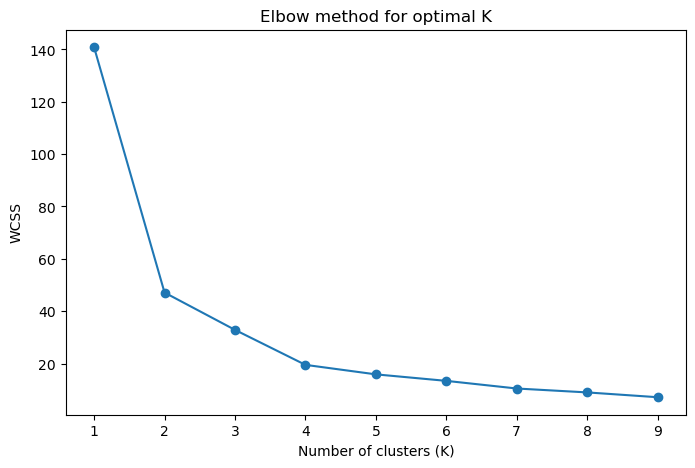

In [113]:
# Elbow method, optimal K
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)
    kmeans.fit(pca_components)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,10), wcss, marker='o',linestyle='-')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow method for optimal K')
plt.show()

*Optimal k=4*

In [114]:
# Kmeans with optimal K
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
arrest_df['Cluster']= kmeans.fit_predict(pca_components)

c:\Users\hawan\anaconda3\envs\team_pipeline\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [115]:
# Validate using silhouette score
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(pca_components, arrest_df['Cluster'])
print(f'Silhouette Score: {silhouette_avg}')

Silhouette Score: 0.4643339143418435


*Relatively good clustering*

### **Gaussian Mixture Model**

c:\Users\hawan\anaconda3\envs\team_pipeline\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hawan\anaconda3\envs\team_pipeline\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hawan\anaconda3\envs\team_pipeline\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hawan\anaconda3\envs\team_pipeline\Lib\site-packages\sklearn\cluster\_

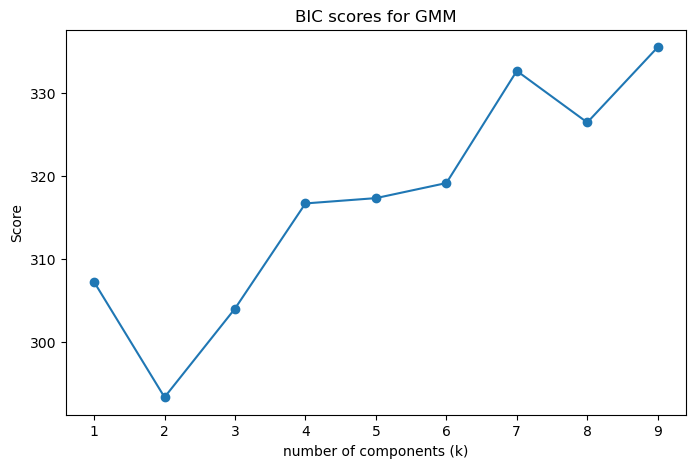

In [116]:
# Elbow Method, optimal k
from sklearn.mixture import GaussianMixture

bic_scores = []
k_val = range(1,10)

for k in k_val:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=10)
    gmm.fit(pca_components)
    bic_scores.append(gmm.bic(pca_components))

# plot AIC and BIC for k
plt.figure(figsize=(8,5))

plt.plot(k_val, bic_scores, marker='o', linestyle='-', label='BIC')
plt.xlabel('number of components (k)')
plt.ylabel('Score')
plt.title('BIC scores for GMM')
plt.show()

*optimal k=2*

In [117]:
opt_k = 2
gmm = GaussianMixture(n_components=opt_k, random_state=42, n_init=10)
gmm.fit(pca_components)

# predict cluster probabilites 
probs = gmm.predict_proba(pca_components)

# assign clusters based on max probabilites
clusters = gmm.predict(pca_components)

c:\Users\hawan\anaconda3\envs\team_pipeline\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hawan\anaconda3\envs\team_pipeline\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hawan\anaconda3\envs\team_pipeline\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hawan\anaconda3\envs\team_pipeline\Lib\site-packages\sklearn\cluster\_

In [118]:
import numpy as np

# min prob per point
min_prob = np.min(probs, axis=1)

#anomaly threshold
threshold = np.percentile(min_prob, 5)

anomalies = min_prob < threshold


In [119]:
silhouette_gmm = silhouette_score(pca_components, clusters)
print('GMM Silhouette Score: ', silhouette_gmm)

GMM Silhouette Score:  0.5609728065820804


*A relatively good clustering score*

### Summary

*States were clustered on violent crime severity using Murder, Assault, and Rape (standardized, PCA-reduced to 2 components retaining 93.9% variance). K-Means (k=4, elbow method) produced four severity tiers with a silhouette of 0.46, while GMM (k=2) found a coarser high/low split with a higher silhouette of 0.56 and additionally flagged a handful of low-confidence states as borderline via its probability outputs — giving a finer discrete breakdown from K-Means alongside a probabilistic, higher-scoring split from GMM.*

### **Visualization**

#### 1. **KMeans**

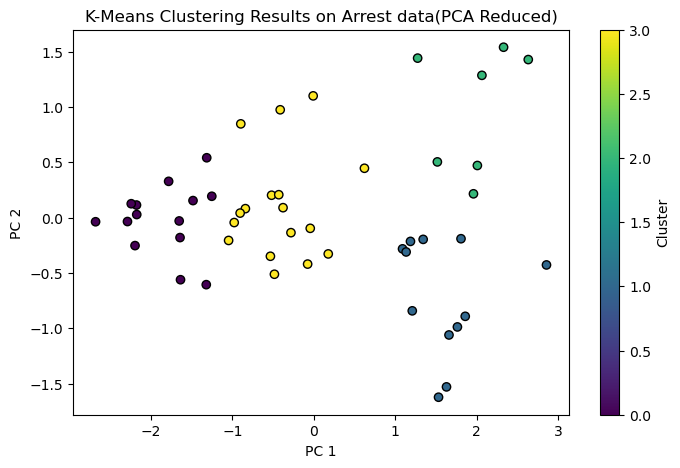

In [120]:
plt.figure(figsize=(8,5))
plt.scatter(pca_components[:, 0], 
            pca_components[:, 1], 
            c=arrest_df['Cluster'],
            cmap='viridis', marker='o', edgecolor='k')

plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("K-Means Clustering Results on Arrest data(PCA Reduced)")
plt.colorbar(label="Cluster")
plt.show()


In [126]:
cluster_means = arrest_df.groupby('Cluster')[['Murder', 'Assault', 'Rape']].mean()
print(cluster_means)

            Murder     Assault       Rape
Cluster                                  
0         3.078571   80.928571  11.800000
1        13.633333  258.166667  23.925000
2        10.100000  261.285714  38.285714
3         6.588235  145.764706  20.076471


In [129]:
for cluster, states in arrest_df.groupby('Cluster')['State']:
    print(f"Cluster {cluster} ({len(states)} states): {list(states)}")

Cluster 0 (14 states): ['Connecticut', 'Hawaii', 'Idaho', 'Iowa', 'Maine', 'Minnesota', 'Nebraska', 'New Hampshire', 'North Dakota', 'Rhode Island', 'South Dakota', 'Vermont', 'West Virginia', 'Wisconsin']
Cluster 1 (12 states): ['Alabama', 'Florida', 'Georgia', 'Illinois', 'Louisiana', 'Maryland', 'Mississippi', 'New York', 'North Carolina', 'South Carolina', 'Tennessee', 'Texas']
Cluster 2 (7 states): ['Alaska', 'Arizona', 'California', 'Colorado', 'Michigan', 'Nevada', 'New Mexico']
Cluster 3 (17 states): ['Arkansas', 'Delaware', 'Indiana', 'Kansas', 'Kentucky', 'Massachusetts', 'Missouri', 'Montana', 'New Jersey', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Utah', 'Virginia', 'Washington', 'Wyoming']


*States split into 4 severity tiers along PC1. Cluster 0 (14 states) is the safest group, Cluster 3 (17 states) sits moderate, and Clusters 1 (12 states) and 2 (7 states) are both high-severity but differ in profile: Cluster 1 skews murder-heavy, while Cluster 2 skews rape-heavy, which is likely what PC2 is picking up.*

#### 2. **Gaussian Mixture Model**

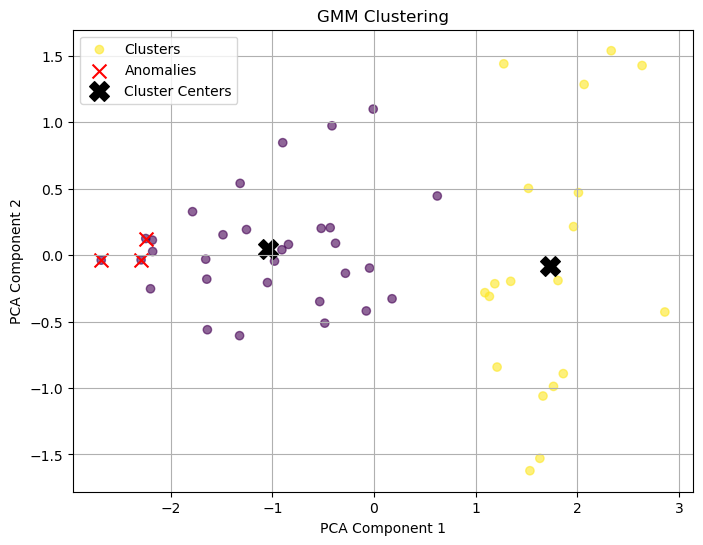

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(    
    pca_components[:, 0],
    pca_components[:, 1],
    c=clusters,
    cmap='viridis',
    alpha=0.6,
    label='Clusters')

plt.scatter(
    pca_components[anomalies, 0],
    pca_components[anomalies, 1],
    color='red',
    marker='x',
    s=100,
    label='Anomalies'
)
plt.scatter(
    gmm.means_[:, 0],
    gmm.means_[:, 1],
    s=200,
    c='black',
    marker='X',
    label='Cluster Centers'
)

plt.title('GMM Clustering')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True)
plt.show()

In [128]:
arrest_df.loc[anomalies, 'State']

28    New Hampshire
33     North Dakota
44          Vermont
Name: State, dtype: str

*GMM collapses this into a coarser high/low split, with the two black X's marking each Gaussian's center. The red-flagged "anomalies" (NH, ND, VT) aren't border cases between clusters; they're all in the lowest-crime cluster already, just sitting furthest into that group's extreme, which is why the model is least confident classifying them despite them being unambiguously low-crime.*